(1427, 2100, 3)


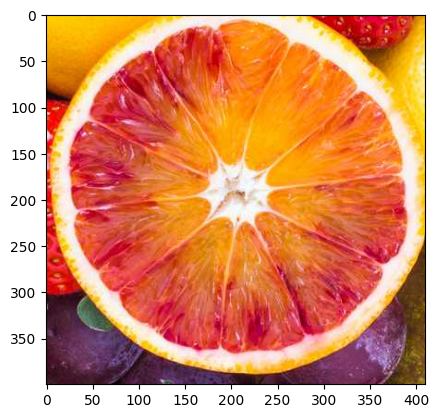

In [1]:
# Bài Tập Lý Thuyết
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('fruit.jpg')
bmg = data [800:1200, 570:980]
print (data.shape)
iio.imsave('orange.jpg', bmg)
plt.imshow (bmg)
plt.show ()


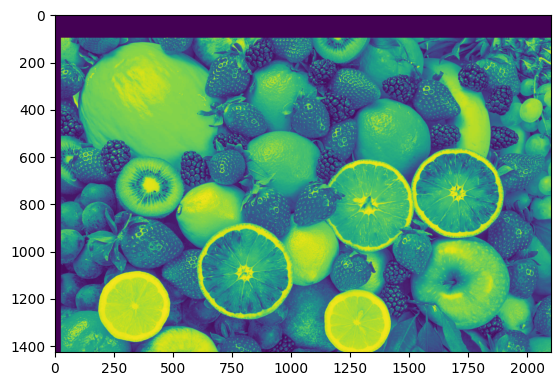

In [3]:
#1.2. Tịnh tiến đơn
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('fruit.jpg', mode ="L")
bdata = nd.shift (data, (100, 25))
plt.imshow (bdata)
plt.show ()



Kích thước ảnh gốc: (1427, 2100, 3)
Kích thước ảnh sau khi phóng to 2x: (2854, 4200, 3)
Kích thước ảnh sau khi thu nhỏ: (714, 1890, 3)


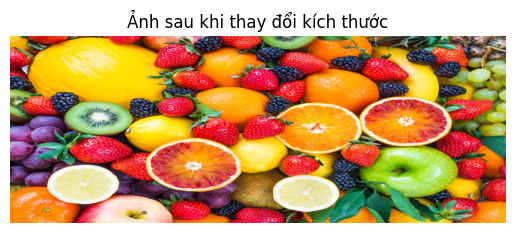

In [1]:
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt

# Đọc ảnh
data = iio.imread('fruit.jpg')
print("Kích thước ảnh gốc:", data.shape)

# Phóng to 2 lần (chỉ chiều cao và rộng, không thay đổi chiều màu)
data2 = nd.zoom(data, (2, 2, 1))
print("Kích thước ảnh sau khi phóng to 2x:", data2.shape)

# Thu nhỏ theo tỉ lệ khác nhau
data3 = nd.zoom(data, (0.5, 0.9, 1))
print("Kích thước ảnh sau khi thu nhỏ:", data3.shape)

# Hiển thị ảnh kết quả
plt.imshow(data3)
plt.title("Ảnh sau khi thay đổi kích thước")
plt.axis('off')
plt.show()


(1427, 2100, 3)


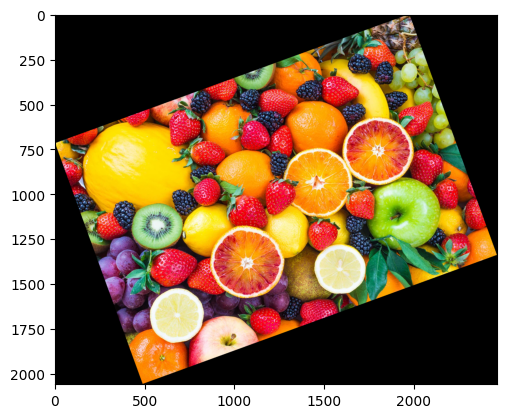

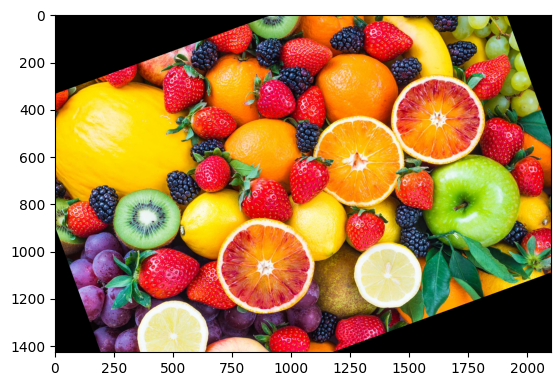

In [3]:
#1.4. Xoay ảnh
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('fruit.jpg')
print (data.shape)
d1 = nd.rotate (data, 20)
plt.imshow (d1)
plt.show ()
d2 = nd.rotate (data, 20, reshape=False)
plt.imshow (d2)
plt.show ()



(309, 515)


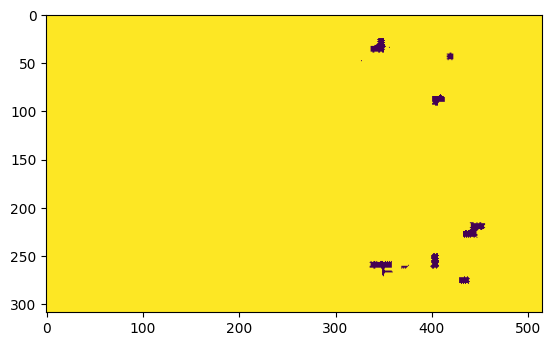

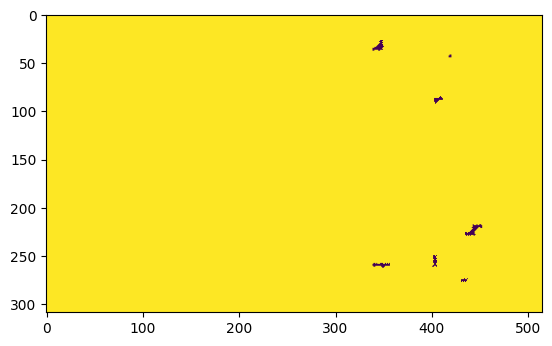

In [7]:
#1.5. Dilation và Erosion
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('world_cup.jpg', mode="L")
print (data.shape)
d1 = nd.binary_dilation (data)
plt.imshow (d1)
plt.show ()
d2 = nd.binary_dilation (data, iterations=3)
plt.imshow (d2)
plt.show ()

(309, 515)


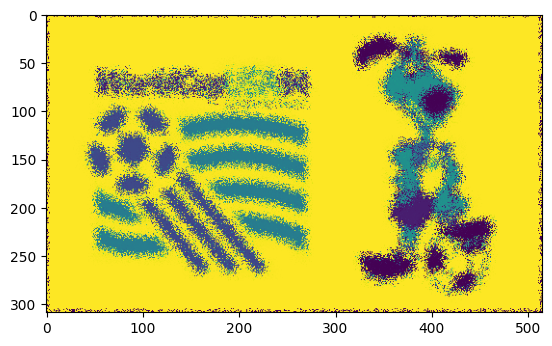

In [8]:
#1.6. Coordinate Mapping
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('world_cup.jpg', mode="L")
print (data.shape)
V, H= data.shape
M = np.indices((V, H))
d = 5
q=2 * d * np.random.ranf (M.shape) - d
mp = (M + q).astype (int)
dl = nd.map_coordinates (data, mp)
plt.imshow (dl)
plt.show ()


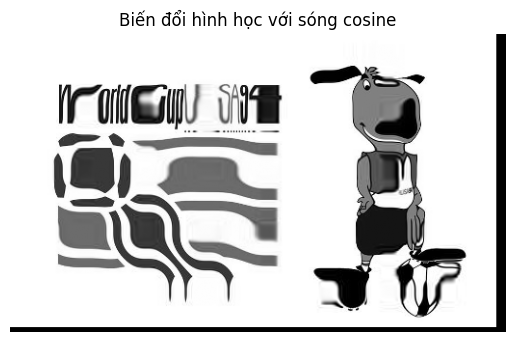

In [11]:
#1.7. Biến đổi chung (Generic Transformation)
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pyplot as plt

# Hàm biến đổi tọa độ (biến dạng sóng)
def GeoFun(outcoord):
    a = 10 * np.cos(outcoord[0] / 10.0) + outcoord[0]
    b = 10 * np.cos(outcoord[1] / 10.0) + outcoord[1]
    return a, b

# Đọc ảnh xám
data = iio.imread('world_cup.jpg', mode='L')

# Áp dụng phép biến đổi hình học
d1 = nd.geometric_transform(data, GeoFun)

# Hiển thị ảnh kết quả
plt.imshow(d1, cmap='gray')
plt.title("Biến đổi hình học với sóng cosine")
plt.axis('off')
plt.show()



In [ ]:
# 2. BÀI TẬP
# 1. Viết chương trình chọn quả kiwi từ ảnh colorful-ripe-tropical-fruits.jpg trong thư mục
# exercise. Tinh tiến quả kiwi sang phải 30 pixels.
# 2. Viết chương trình chọn quả đu đủ và quả dưa hấu từ ảnh colorful-ripe-tropical-fruits.jpg trong
# thư mục exercise. Đổi màu hai đối tượng này.
# 3. Viết chương trình chọn ngọn núi và con thuyền từ ảnh quang_ninh.jpg trong thư mục
# exercise. Xoay 2 đối tượng này 1 góc 45 độ và lưu vào máy.
# 4. Viết chương trình chọn ngôi chùa từ ảnh pagoda.jpg trong thư mục exercise. Tăng kích thước
# ngôi chùa lên 5 lần và lưu vào máy.
# 5. Viết chương trình tạo menu
# - Tịnh tiến
# - Xoay
# - Phóng to
# - Thu nhỏ
# - Coordinate Map
# Khi chọn phím T, X, P, H, C thì hỏi muốn thực hiện trên hình nào từ 3 hình trong thư mục
# exercise. Người dùng chọn hình nào thì thực hiện phép biến đổi trên hình đó.


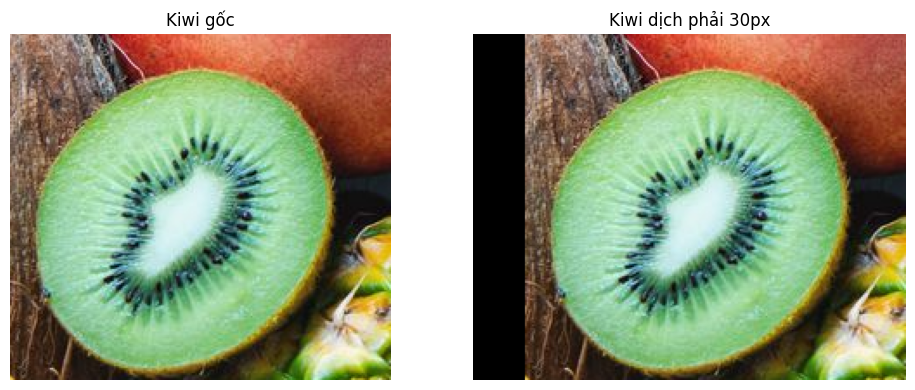

In [5]:
# 1. Viết chương trình chọn quả kiwi từ ảnh colorful-ripe-tropical-fruits.jpg trong thư mục exercise. Tinh tiến quả kiwi sang phải 30 pixels.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh từ tệp bạn tải lên
img = cv2.imread('exercise/colorful-ripe-tropical-fruits.jpg')

# Kiểm tra ảnh có đọc được không
if img is None:
    print("Không đọc được ảnh.")
    exit()

# ====== CẮT QUẢ KIWI (một lát trái gần dứa) ======
kiwi = img[900:1100, 380:600]  # (Y1:Y2, X1:X2)

# ====== DỊCH SANG PHẢI 30 PIXELS ======
M = np.float32([[1, 0, 30], [0, 1, 0]])  # Ma trận tịnh tiến
shifted_kiwi = cv2.warpAffine(kiwi, M, (kiwi.shape[1] + 30, kiwi.shape[0]))

# ====== CHUYỂN BGR → RGB ======
kiwi_rgb = cv2.cvtColor(kiwi, cv2.COLOR_BGR2RGB)
shifted_rgb = cv2.cvtColor(shifted_kiwi, cv2.COLOR_BGR2RGB)

# ====== HIỂN THỊ BẰNG MATPLOTLIB ======
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(kiwi_rgb)
plt.title("Kiwi gốc")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(shifted_rgb)
plt.title("Kiwi dịch phải 30px")
plt.axis('off')

plt.tight_layout()
plt.show()




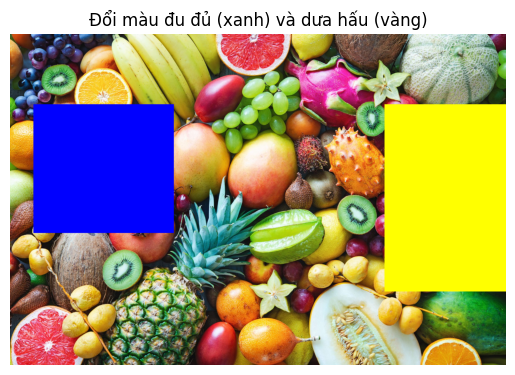

In [7]:
#2. Viết chương trình chọn quả đu đủ và quả dưa hấu từ ảnh colorful-ripe-tropical-fruits.jpg trong thư mục exercise. Đổi màu hai đối tượng này.

import cv2
import matplotlib.pyplot as plt

# Đọc ảnh và chuyển sang RGB để hiển thị đúng màu
img = cv2.imread('exercise/colorful-ripe-tropical-fruits.jpg')
if img is None:
    print("Không tìm thấy ảnh.")
    exit()

# Đổi từ BGR -> RGB để hiển thị bằng matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Sao chép ảnh để xử lý
result = img_rgb.copy()

# Tô màu quả đu đủ (màu xanh lam: [0, 0, 255])
result[300:850, 100:700] = [0, 0, 255]

# Tô màu quả dưa hấu (màu vàng: [255, 255, 0])
result[300:1100, 1600:2200] = [255, 255, 0]

# Hiển thị kết quả
plt.imshow(result)
plt.title("Đổi màu đu đủ (xanh) và dưa hấu (vàng)")
plt.axis("off")
plt.show()


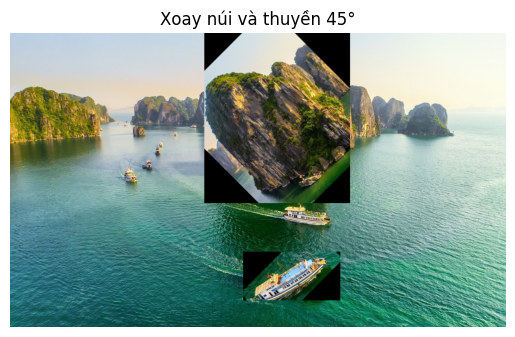

In [10]:
#3. Viết chương trình chọn ngọn núi và con thuyền từ ảnh quang_ninh.jpg trong thư mục
#exercise. Xoay 2 đối tượng này 1 góc 45 độ và lưu vào máy.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('exercise/quang_ninh.jpg')

# Hàm xoay vùng ảnh
def xoay_vung(anh, x1, y1, x2, y2):
    vung = anh[y1:y2, x1:x2]
    h, w = vung.shape[:2]
    tam = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(tam, 45, 1.0)
    vung_xoay = cv2.warpAffine(vung, M, (w, h))
    anh[y1:y2, x1:x2] = vung_xoay

# Xoay ngọn núi
xoay_vung(img, 400, 0, 700, 350)

# Xoay con thuyền
xoay_vung(img, 480, 450, 680, 550)

# Lưu ảnh
cv2.imwrite('quang_ninh_xoay_45.jpg', img)

# Hiển thị
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Xoay núi và thuyền 45°')
plt.axis('off')
plt.show()



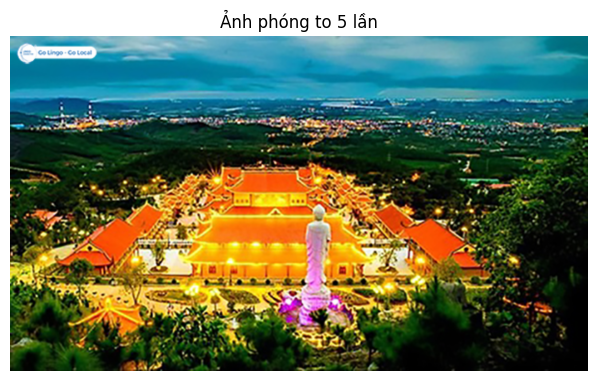

In [15]:
#4. Viết chương trình chọn ngôi chùa từ ảnh pagoda.jpg trong thư mục exercise. Tăng kích thước
# ngôi chùa lên 5 lần và lưu vào máy.
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh gốc
img = cv2.imread('exercise/pagoda.jpg')

# Lấy kích thước gốc
h, w = img.shape[:2]

# Tính kích thước mới (phóng to 5 lần)
new_w, new_h = w * 5, h * 5

# Resize ảnh
img_zoom = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

# Chuyển BGR sang RGB để hiển thị với matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_zoom_rgb = cv2.cvtColor(img_zoom, cv2.COLOR_BGR2RGB)

# Lưu ảnh đã phóng to
cv2.imwrite('pagoda_zoom5.jpg', img_zoom)

# Hiển thị ảnh gốc và ảnh phóng to
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 2)
plt.imshow(img_zoom_rgb)
plt.title("Ảnh phóng to 5 lần")
plt.axis('off')

plt.tight_layout()
plt.show()



CHỌN PHÉP BIẾN ĐỔI:
T - Tịnh tiến
X - Xoay
P - Phóng to
H - Thu nhỏ
C - Coordinate Map

CHỌN HÌNH:
1 - colorful-ripe-tropical-fruits.jpg
2 - quang_ninh.jpg
3 - pagoda.jpg


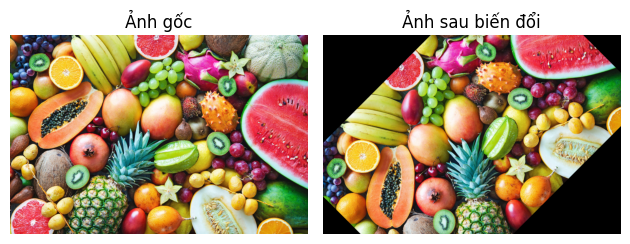

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Danh sách tên ảnh trong thư mục 'exercise'
images = {
    "1": "exercise/colorful-ripe-tropical-fruits.jpg",
    "2": "exercise/quang_ninh.jpg",
    "3": "exercise/pagoda.jpg"
}

# Hiển thị menu
print("CHỌN PHÉP BIẾN ĐỔI:")
print("T - Tịnh tiến")
print("X - Xoay")
print("P - Phóng to")
print("H - Thu nhỏ")
print("C - Coordinate Map")

choice = input("Nhập ký tự tương ứng: ").upper()

if choice not in ['T', 'X', 'P', 'H', 'C']:
    print("Lựa chọn không hợp lệ.")
    exit()

# Chọn hình
print("\nCHỌN HÌNH:")
print("1 - colorful-ripe-tropical-fruits.jpg")
print("2 - quang_ninh.jpg")
print("3 - pagoda.jpg")
img_choice = input("Chọn số hình (1-3): ")

if img_choice not in images:
    print("Hình không hợp lệ.")
    exit()

# Đọc ảnh
img = cv2.imread(images[img_choice])

# Biến đổi tương ứng
if choice == 'T':  # Tịnh tiến sang phải 50px và xuống 30px
    M = np.float32([[1, 0, 50], [0, 1, 30]])
    transformed = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

elif choice == 'X':  # Xoay 45 độ quanh tâm ảnh
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, 45, 1.0)
    transformed = cv2.warpAffine(img, M, (w, h))

elif choice == 'P':  # Phóng to 2 lần
    transformed = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)

elif choice == 'H':  # Thu nhỏ 0.5 lần
    transformed = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

elif choice == 'C':  # Hiện bản đồ tọa độ bằng sự kiện click
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    def onclick(event):
        if event.xdata and event.ydata:
            x, y = int(event.xdata), int(event.ydata)
            print(f"👉 Tọa độ bạn click: X = {x}, Y = {y}")
    fig, ax = plt.subplots()
    ax.imshow(img_rgb)
    ax.set_title("Click để lấy tọa độ")
    fig.canvas.mpl_connect('button_press_event', onclick)
    plt.axis('on')
    plt.show()
    exit()

# Nếu không phải C thì hiển thị ảnh gốc và kết quả
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
transformed_rgb = cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB)

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_rgb)
plt.title("Ảnh sau biến đổi")
plt.axis('off')

plt.tight_layout()
plt.show()

